Practica 1

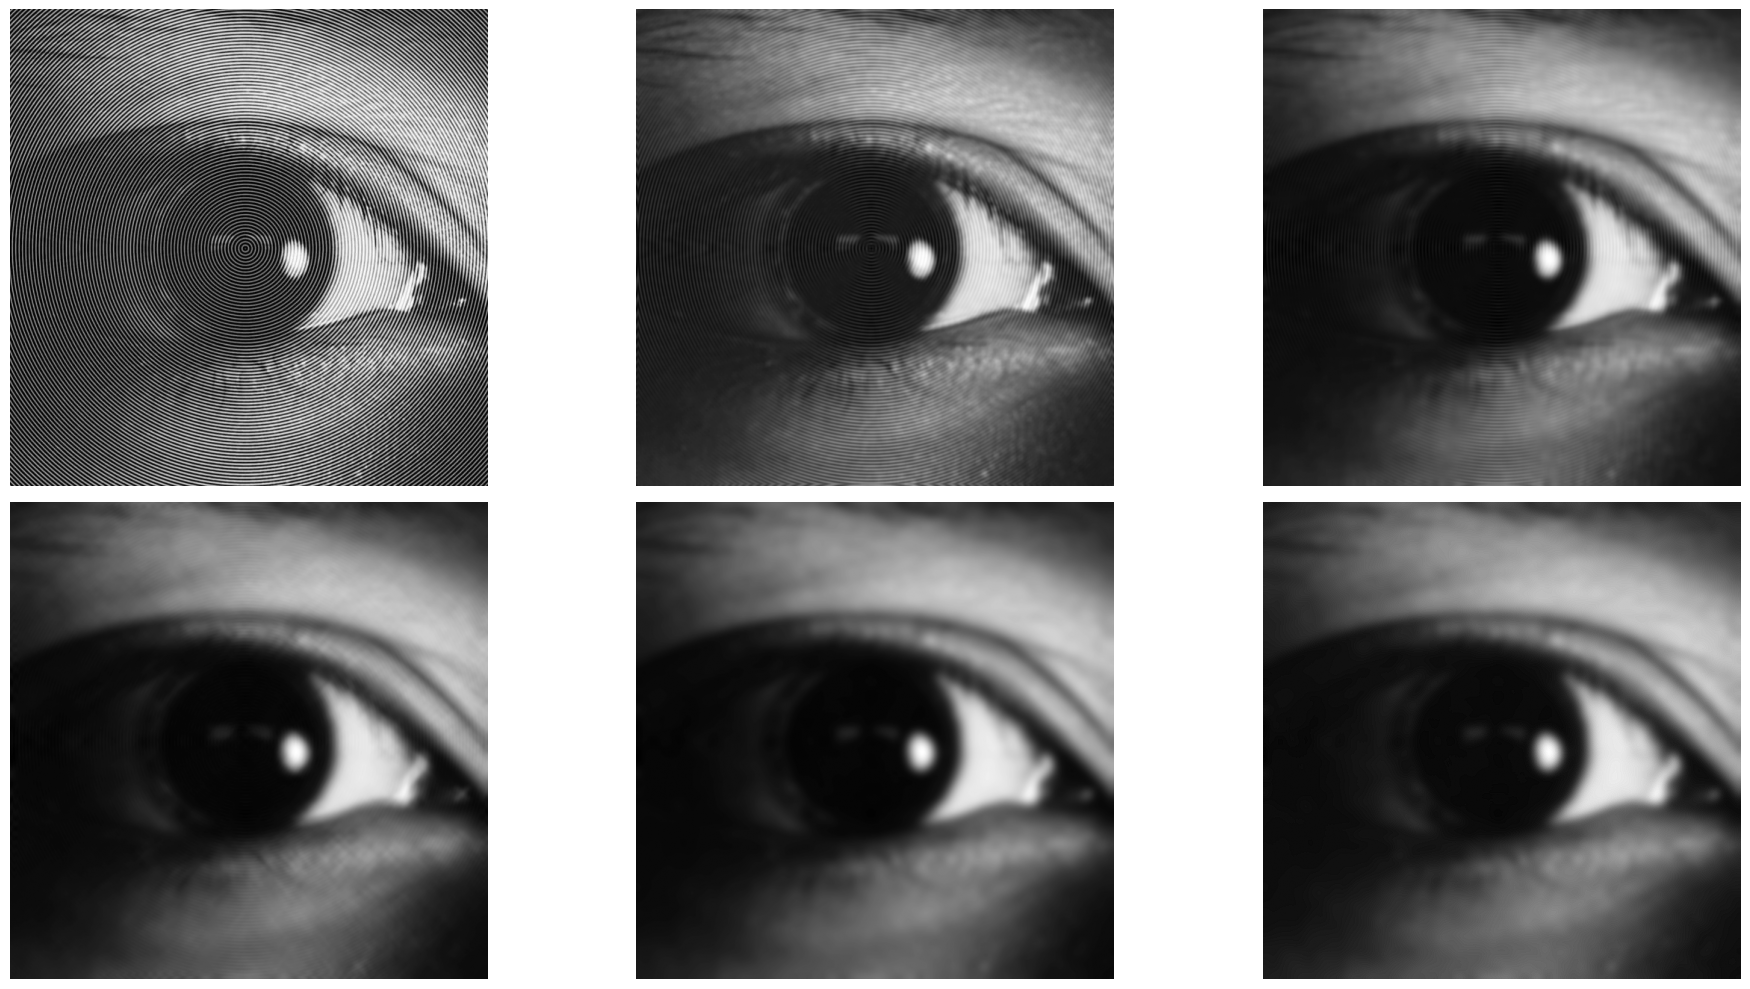

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Ojo.jpg", cv2.IMREAD_GRAYSCALE)

def kernel_media(t):
    k = np.ones((t, t), np.float32)
    return k / np.sum(k)

def kernel_cruz(t):
    k = np.zeros((t, t), np.float32)
    c = t // 2
    k[c, :] = 1
    k[:, c] = 1
    return k / np.sum(k)

def kernel_x(t):
    k = np.zeros((t, t), np.float32)
    for i in range(t):
        k[i, i] = 1
        k[i, t - 1 - i] = 1
    return k / np.sum(k)

def kernel_enfoque():
    return np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ], dtype=np.float32)

def kernel_suavizado_circular(t):
    k = np.zeros((t, t), np.float32)
    c = t // 2
    r = t // 2
    for i in range(t):
        for j in range(t):
            if (i - c) ** 2 + (j - c) ** 2 <= r ** 2:
                k[i, j] = 1
    return k / np.sum(k)

k1 = kernel_media(7)
k2 = kernel_cruz(17)
k3 = kernel_x(17)
k4 = kernel_suavizado_circular(15)
k5 = kernel_enfoque()

suave1 = cv2.filter2D(img, -1, k1)
suave2 = cv2.filter2D(suave1, -1, k2)
suave3 = cv2.filter2D(suave1, -1, k3)

mezcla1 = cv2.addWeighted(suave2, 0.5, suave3, 0.5, 0)
mezcla2 = cv2.filter2D(mezcla1, -1, k4)
final = cv2.filter2D(mezcla2, -1, k5)

plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(suave1, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(suave2, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(suave3, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(mezcla2, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(final, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(666.5), np.float64(999.5), np.float64(-0.5))

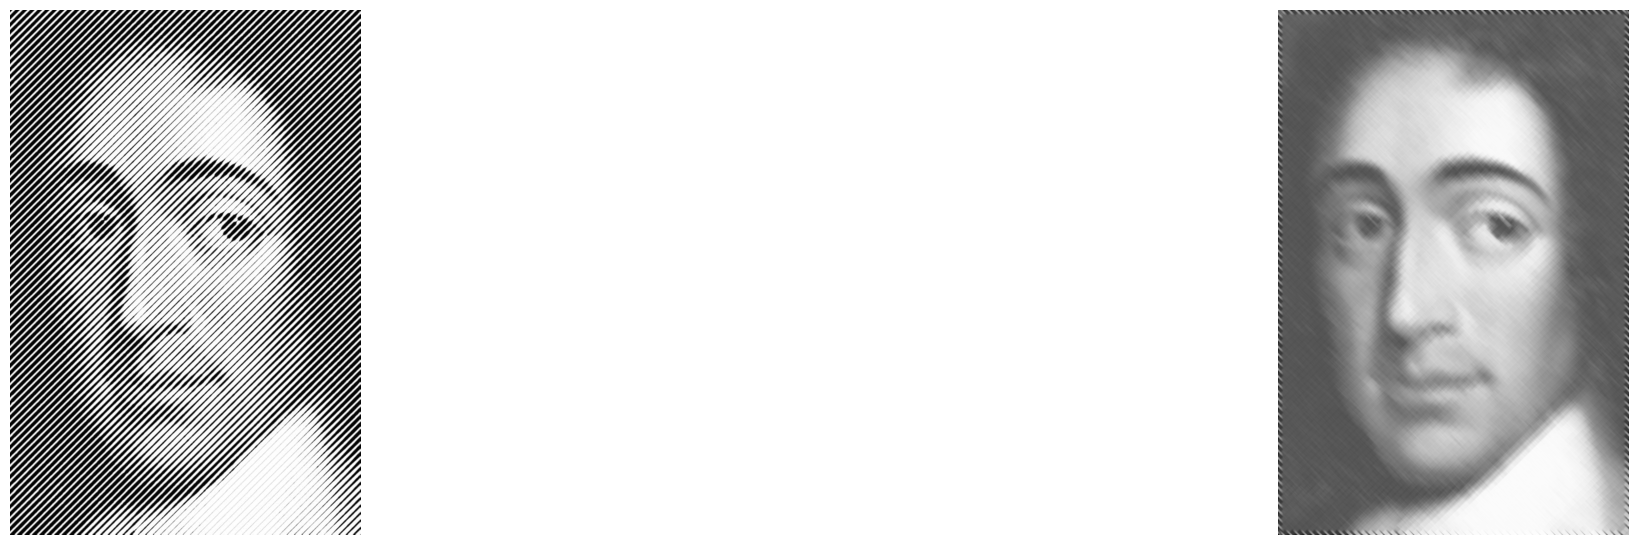

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Pepe.jpg", cv2.IMREAD_GRAYSCALE)

def kernel_diagonal(t):
    k = np.zeros((t, t), np.float32)
    for i in range(t):
        k[i, i] = 1
    return k / np.sum(k)

def kernel_diagonal_inverso(t):
    k = np.zeros((t, t), np.float32)
    for i in range(t):
        k[i, t - 1 - i] = 1
    return k / np.sum(k)

def kernel_media(t):
    k = np.ones((t, t), np.float32)
    return k / np.sum(k)

def kernel_enfoque():
    return np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ], dtype=np.float32)

def kernel_realce_horizontal():
    return np.array([
        [-1, -1, -1],
        [ 2,  2,  2],
        [-1, -1, -1]
    ], dtype=np.float32)

def kernel_realce_vertical():
    return np.array([
        [-1,  2, -1],
        [-1,  2, -1],
        [-1,  2, -1]
    ], dtype=np.float32)

k1 = kernel_diagonal(21)
k2 = kernel_diagonal_inverso(21)
k3 = kernel_media(5)
k4 = kernel_enfoque()
k5 = kernel_realce_horizontal()
k6 = kernel_realce_vertical()

suave1 = cv2.filter2D(img, -1, k1)
suave2 = cv2.filter2D(img, -1, k2)
mezcla1 = cv2.addWeighted(suave1, 0.5, suave2, 0.5, 0)

suave3 = cv2.filter2D(mezcla1, -1, k3)
realce_h = cv2.filter2D(suave3, -1, k5)
realce_v = cv2.filter2D(suave3, -1, k6)
mezcla2 = cv2.addWeighted(realce_h, 0.5, realce_v, 0.5, 0)

final = cv2.filter2D(mezcla2, -1, k4)

plt.figure(figsize=(30, 15))


plt.subplot(2, 2, 2)
plt.imshow(suave1, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.axis("off")







Imágenes moiré y anti-aliasing

1. ¿Qué es el efecto moiré?

El efecto moiré es una distorsión visual que aparece cuando dos patrones repetitivos se superponen o cuando una imagen con detalles muy finos es capturada o mostrada con una resolución que no alcanza para representarlos bien.

Se ve como:

* líneas onduladas,
* franjas falsas,
* rejillas extrañas,
* patrones que no existen en la imagen real.

En otras palabras, el moiré es un patrón artificial generado por interferencia entre estructuras repetitivas.



2. ¿Por qué aparece el moiré?

Aparece principalmente por estas razones:

a) Superposición de patrones periódicos

Cuando dos tramas o rejillas se cruzan con una frecuencia parecida, se genera una interferencia visible.

Ejemplos:

* fotografiar una pantalla,
* escanear una imagen impresa,
* tomar foto de una tela con rayas finas,
* capturar una imagen con líneas muy juntas.

b) Muestreo insuficiente

Si la cámara o el sistema digital no tiene suficiente resolución para representar detalles pequeños, esos detalles se “confunden” y aparecen patrones falsos.

c) Aliasing

El moiré está muy relacionado con el aliasing, porque ambos surgen cuando una señal visual tiene frecuencias más altas de las que pueden muestrearse correctamente.


3. Relación entre moiré y aliasing

El aliasing ocurre cuando una señal continua se digitaliza con una frecuencia de muestreo insuficiente. En imágenes, eso significa que detalles muy finos no pueden representarse correctamente.

Entonces:

* aliasing = error de muestreo,
* moiré = una manifestación visual del aliasing en patrones repetitivos.

O sea, el moiré puede entenderse como un caso particular de aliasing en imágenes con texturas periódicas o estructuras repetidas.



4. ¿Qué es anti-aliasing?

El anti-aliasing es el conjunto de técnicas que se usan para reducir el aliasing y hacer que la imagen se vea más suave, más natural y con menos bordes dentados o patrones falsos.

Sirve para:

* reducir bordes en escalera,
* disminuir ruido visual,
* evitar patrones moiré,
* mejorar la apariencia general.


5. ¿Cómo ayuda el anti-aliasing contra el moiré?

El problema aparece porque hay detalles demasiado finos para la resolución disponible. Entonces, el anti-aliasing intenta:

* suavizar frecuencias altas,
* eliminar detalles excesivamente finos antes del muestreo,
* promediar transiciones bruscas,
* evitar que aparezcan patrones falsos.

En imágenes, esto suele lograrse con filtros de suavizado, especialmente paso bajo, como:

* filtro promedio,
* filtro gaussiano,
* filtro de mediana en algunos casos,
* convoluciones direccionales si el patrón tiene orientación definida.


6. Moiré en procesamiento digital de imágenes

En procesamiento de imágenes, el moiré aparece mucho en:

* fotos de pantallas,
* imágenes escaneadas,
* documentos impresos,
* telas o superficies con tramas,
* imágenes comprimidas o reescaladas,
* patrones diagonales o cuadriculados.

Cuando el daño sigue una dirección específica, por ejemplo diagonal, se pueden usar filtros orientados en esa dirección.

Por eso, si una imagen presenta líneas diagonales repetidas, tiene sentido aplicar:

* convolución diagonal,
* convolución diagonal inversa,
* suavizado espacial,
* realce posterior.


7. Filtro de mediana y moiré

El filtro de mediana no es una convolución, pero es útil porque reemplaza cada píxel por la mediana de su vecindad.

Sus ventajas son:

* reduce ruido impulsivo,
* atenúa detalles finos molestos,
* conserva mejor los bordes que un promedio simple.

En imágenes con moiré, puede ayudar cuando el patrón no es demasiado fuerte o cuando está mezclado con ruido fino.

Pero hay que decir algo importante:

* el filtro de mediana no siempre elimina completamente el moiré,
* en patrones periódicos fuertes, suele funcionar mejor combinarlo con filtros lineales o direccionales.


8. Convoluciones diagonales en imágenes con moiré

Si el patrón moiré tiene orientación diagonal, se puede construir un kernel que promedie solamente en la diagonal principal o en la diagonal secundaria.

Eso ayuda a:

* suavizar las líneas de interferencia,
* seguir la dirección del ruido,
* reducir el patrón sin afectar igual todas las direcciones.

Por ejemplo:

Diagonal principal

1 0 0
0 1 0
0 0 1

Diagonal inversa

0 0 1
0 1 0
1 0 0

Normalizados, estos kernels hacen un promedio diagonal. Si se usan en tamaños grandes, como 15x15, 21x21 o 31x31, el efecto de suavizado es mayor.


9. Estrategia típica para corregir moiré

Una estrategia razonable es esta:

Paso 1. Suavizado inicial

Aplicar un filtro de mediana o promedio para reducir ruido fino.

Paso 2. Filtro direccional

Aplicar convolución diagonal y diagonal inversa si el patrón tiene inclinación.

Paso 3. Combinación

Promediar los resultados de ambos filtros.

Paso 4. Mejora visual

Aplicar un kernel de enfoque suave para recuperar nitidez.

Así se busca un equilibrio entre:

* quitar el patrón moiré,
* no borrar demasiado la imagen,
* recuperar detalle.


10. Diferencia entre suavizar y enfocar

En restauración de imágenes con moiré hay una tensión importante:

* si suavizas demasiado, desaparece el ruido pero también los detalles,
* si enfocas demasiado, vuelven a aparecer artefactos.

Por eso normalmente se hace:

1. primero reducción del patrón,
2. después realce moderado.

Ese orden es clave.


11. Aplicaciones del anti-aliasing

El anti-aliasing se usa en muchas áreas:

* gráficos por computadora,
* videojuegos,
* renderizado 3D,
* edición de imágenes,
* fotografía digital,
* escaneo de documentos,
* representación de texto en pantallas.

En videojuegos, por ejemplo, reduce el efecto de “dientes de sierra” en bordes inclinados. En imágenes, ayuda a disminuir errores de muestreo y patrones artificiales.


12. Tipos generales de anti-aliasing

En forma general, existen varias formas de anti-aliasing:

a) Óptico

Se usa antes de capturar la imagen, por ejemplo con filtros físicos en cámaras.

b) Espacial

Se aplica directamente sobre la imagen con filtros de suavizado.

c) Por sobremuestreo

Se trabaja con más resolución y luego se reduce.

d) Temporal

Se usa en video o gráficos en movimiento aprovechando varios cuadros.

Para tu caso, lo importante es el anti-aliasing espacial, porque se trabaja con kernels sobre la imagen.

13. Ventajas y limitaciones

Ventajas

* reduce patrones falsos,
* mejora apariencia visual,
* suaviza interferencias,
* puede recuperar legibilidad.

Limitaciones

* no siempre elimina totalmente el moiré,
* puede borrar textura real,
* si el patrón es muy fuerte, se necesita un método más avanzado,
* el resultado depende mucho del tamaño del kernel y del tipo de imagen.


14. Conclusión

El efecto moiré es una distorsión visual causada por interferencia entre patrones repetitivos o por muestreo insuficiente. Está directamente relacionado con el aliasing, ya que ambos surgen cuando los detalles finos de una imagen no pueden representarse correctamente.

El anti-aliasing busca reducir ese problema mediante técnicas de suavizado y muestreo adecuado. En el procesamiento digital de imágenes, una forma práctica de tratar el moiré consiste en usar filtros espaciales, como el filtro de mediana y convoluciones direccionales. Cuando la interferencia tiene orientación diagonal, los kernels diagonales e inversos son especialmente útiles, porque atacan el patrón en la dirección en que aparece.

En consecuencia, la restauración de imágenes con moiré puede lograrse combinando suavizado, filtrado direccional y enfoque moderado, con el objetivo de disminuir la interferencia sin perder demasiado detalle de la imagen original.



15. Resumen corto para exponer

Puedes decirlo así:

El moiré es un patrón visual falso que aparece cuando hay interferencia entre estructuras repetitivas o cuando una imagen se digitaliza con poca resolución. Está relacionado con el aliasing, que es un error de muestreo. Para reducir este problema se usa anti-aliasing, que suaviza las altas frecuencias y evita que aparezcan patrones falsos. En imágenes con líneas diagonales, una buena solución es aplicar filtro de mediana y convoluciones diagonales, porque permiten disminuir el patrón no deseado y mejorar la imagen final.

